# 4x3 Grid World: Monte Carlo Methods

This notebook applies simple MC methods to the 4x3 Grid World with non-deterministic actions.

## Installation and Setup

In [1]:
# uncomment if needed
# %pip install "gym-classics2 @ git+https://github.com/mhahsler/gym-classics2.git"

In [2]:
import numpy as np
np.set_printoptions(precision=2)

SEED = 42
rng = np.random.default_rng(SEED)

In [3]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

## Define the $4 \times 3$ Grid World

The used example is the simple $4 \times 3$ grid world described in AIMA Chapter 17.

![4x3 grid world description](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/AIMA_Figure_17_1.png)

AIMA Figure 17.1: (a) A simple, stochastic 
 environment that presents the agent with a sequential decision problem. (b) Illustration of the transition model of the environment: the “intended” outcome occurs with probability 0.8, but with probability 0.2 the agent moves at right angles to the intended direction. A collision with a wall results in no movement. Transitions into the two terminal states have reward +1 and -1, respectively, and all other transitions have a reward of -0.04.

The patched `gym-classic` already defined this environment.

In [4]:
gym_env = gym.make('ClassicGridworld-v1', tabular = True)
env = gym_env.unwrapped
env.reset(seed=SEED)

(0, {})

Show the state layout. Unreachable states are not stored and shown as -1.

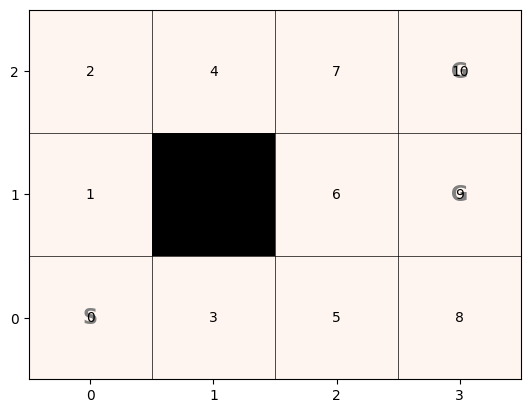

In [5]:
env.image()

## Monte Carlo Prediction

Estimate the value function for a policy using sample trajectories. This is also called policy evaluation. 

We already know that we can use sampling
many trajectories from a state to estimate the state value using the average return. The idea here is that the estimate for each state in the episode can be updated with the
return over the rest of the episode.  

![Monte Carlo Prediciton](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_MC_Prediction.png)

In [6]:
manual_pol = [env.action2id("up")] * len(env.states())
manual_pol[2] = env.action2id("right")
manual_pol[4] = env.action2id("right")
manual_pol[7] = env.action2id("right")

manual_pol

[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0]

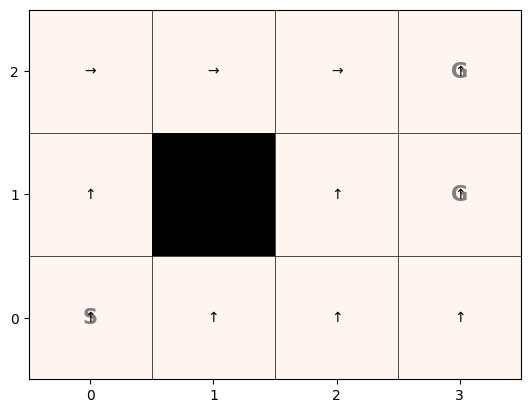

In [7]:
env.image(policy = manual_pol)

Sample complete episodes. The starting (s,a) can be specified (used for exploring starts).

In [8]:
def sample_episode(env, policy, start_state = None, start_action = None, max_len = 1000):
 
    episode = []
    
    s, r = env.reset()
    
    # set starting state
    if not start_state is None:
        s = start_state
        env.state = env.id2state(s) ### gym-classic environments store (x,y) as the internal state
    
    step = 0
    done = False
    while not done and step < max_len:
        a = policy[s]
        
        # override policy for the starting action
        if step == 0 and not start_action is None:
            a = start_action
        
        sp, reward, done, _, _ = env.step(a)
        episode.append((s,a,reward,sp))
        
        s = sp
        step += 1
        
    return(episode)

In [9]:
sample_episode(env, manual_pol)

[(0, 0, -0.04, 1),
 (1, 0, -0.04, 2),
 (2, 1, -0.04, 4),
 (4, 1, -0.04, 7),
 (7, 1, -0.04, 7),
 (7, 1, -0.04, 6),
 (6, 0, -0.04, 7),
 (7, 1, 1.0, 10)]

The episode can be visualized

In [10]:
# download if missing
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py", 
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/common/")

In [11]:
from gymnasium_display_recorder import VideoWrapper, show

gym_env_vis = gym.make('ClassicGridworld-v1', tabular = True, render_mode = "rgb_array")
env_record = VideoWrapper(gym_env_vis, 'GW', render_fps=1)
env_record.reset(seed=SEED)

Videos already exist, I remove them first!


/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/mhahsler/github/Introduction_to_Reinforcement_Learning/MC/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


(0, {})

In [12]:
sample_episode(env_record, manual_pol)
show(env_record)

env_record.close()

Showing: ./videos/video_GW-episode-1.mp4


Now we can implement MC prediction.

In [13]:
def MC_prediction(env, policy, discount, n = 100):
    #V = np.zeros(len(env.states()))
    # we will create the array later
    
    Returns = [[] for _ in env.states()]
    
    for i in range(n):
        episode = sample_episode(env, policy)
        G = 0
        
        # process episode in reverse order
        for t in range(len(episode)-1, -1, -1):
            s,a,r,sp = episode[t]
            G = discount * G + r

            # use first visit only
            if not s in [step[0] for step in episode][0:t]:
                Returns[s].append(G)
                  
    # calculate all state value (np.mean unnecessarily throws a warning for empty lists)
    V = np.array([np.mean(G) if len(G) else np.nan for G in Returns])
    return V  

In [14]:
V_MC = MC_prediction(env, manual_pol, discount=1, n=1000)
V_MC

array([ 0.72,  0.81,  0.86,  0.4 ,  0.92,  0.5 ,  0.73,  0.96, -0.73,
         nan,   nan])

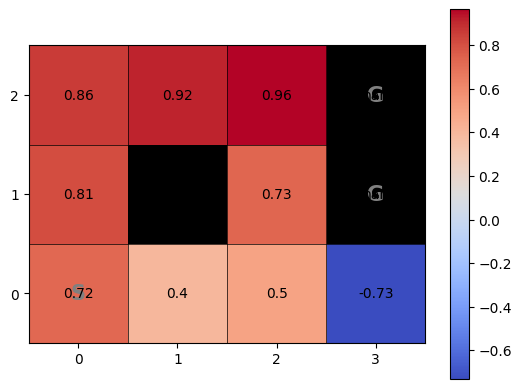

In [15]:
env.image(V_MC, labels = True)

Note: `nan` means that the state does not exist or was never visited. We would need more exploration (e.g., using exploring starts to fix this)! 

### Variance vs Bias

We will estimate $v(s_0)$ (the start state). First, we get the true value using policy evaluation from DP.

In [16]:
from gym_classics2.algorithms.dynamic_programming import policy_evaluation
V = policy_evaluation(env,policy=manual_pol,discount=1)
v_0 = V[0]
v_0

np.float64(0.7111895359123348)

Next, we use MC to estimate $v_0$ and increase the number of episodes used.

In [32]:
# set the seed for the experiment
env.reset(seed=SEED)

episodes = [sample_episode(env, manual_pol) for _ in range(500)]
# we can calculate the returns as the sum of episode rewards since we use no discounting
returns = [sum(np.array(ep)[:,2]) for ep in episodes]


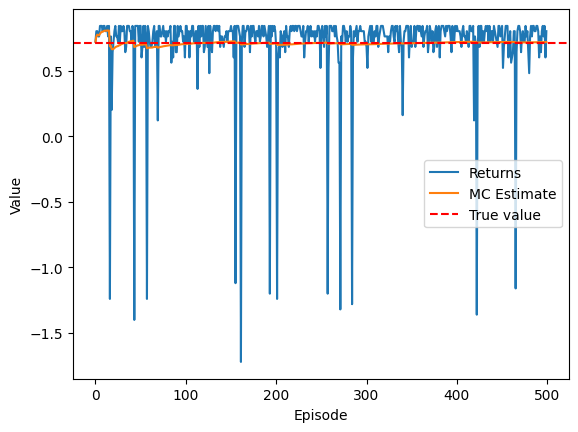

In [33]:
from matplotlib import pyplot as plt

running_avg = np.cumsum(returns) / np.arange(1, len(returns) + 1)

plt.plot(range(len(returns)), returns)
plt.plot(range(len(running_avg)), running_avg)
plt.axhline(y=v_0, color = "red", linestyle = "--")
plt.xlabel("Episode")
plt.ylabel("Value")
plt.legend(["Returns", "MC Estimate", "True value"])
plt.show()

We see that MC has initially a **large variance** and then that the estimate is **unbiased and converges to the true value.**

## Monte Carlo Control

Goal: Find the optimal policy using MC.

Issue: Many $(s,a)$-pairs will never be visited when following $\pi$. We need to keep exploring! 

Options:
* Exploring starts: choose the starting $(s,a)$ for each episode randomly.
* Only consider soft policies like $\epsilon$-greedy. Soft policies have non-zero probabilities for all actions.


### On-policy MC Control with Exploring Starts

Start episodes randomly from all possible $(a,s)$ pairs.

![MC Control with ES](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_MC_Control_ES.png)

In [19]:
from collections import defaultdict
from gym_classics2.algorithms.policy import random_policy
from tqdm import tqdm

# np.argmax does not break ties randomly so we define a version that does.
def random_argmax(x, rng):
        return rng.choice(np.where(x == np.max(x))[0])
        

def MC_control_ES(env, discount, n=100, max_episode_len=100, rng=None): 
    rng = np.random.default_rng(rng)
    policy = random_policy(env, rng=rng)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    Returns = defaultdict(list) # a list for each (s,a)

    
    for i in tqdm(range(n)):
        # Sample starting (s,a)
        s = rng.integers(env.observation_space.n)
        a = rng.integers(env.action_space.n)
        
        episode = sample_episode(env, policy, start_state = s, start_action = a, max_len=max_episode_len)
        G = 0
        
        # for first visit check for (s,a)
        visited = [(s,a) for s,a,r,sp in episode]
        
        # process episode in reverse order
        for t in range(len(episode)-1, -1, -1):
            s,a,r,sp = episode[t]
            G = discount * G + r

            # use first visit of (s,a) only
            if not (s,a) in visited[0:t]:
                Returns[(s,a)].append(G)
            
                # update policy
                Q[s,a] = np.mean(Returns[(s,a)])
                policy[s] = random_argmax(Q[s,:], rng)
          
    return policy, Q

In [35]:
rng = np.random.default_rng(SEED)
pol, Q = MC_control_ES(env, discount=1, n=5000, rng=rng)
pol


100%|██████████| 5000/5000 [00:03<00:00, 1402.89it/s]


array([0, 0, 1, 3, 1, 0, 0, 1, 3, 3, 3])

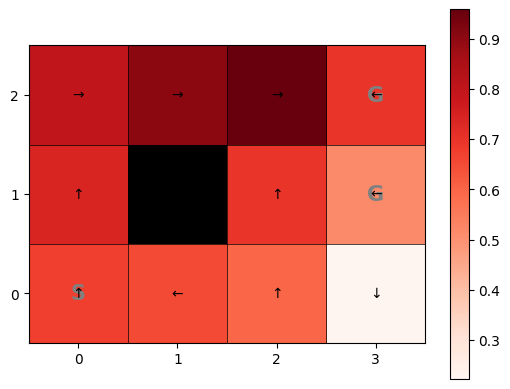

In [21]:
env.image(V = np.max(Q, axis = 1), policy = pol)

**Note:** Goal states are absorbing so actions in the goal states are artifacts and do no matter.

The algorithm also estimates a Q-function with the action values for each state.

In [36]:
Q

array([[ 0.66,  0.45,  0.45,  0.56],
       [ 0.69,  0.55,  0.46,  0.57],
       [ 0.71,  0.74,  0.63,  0.64],
       [ 0.26,  0.47,  0.43,  0.66],
       [ 0.55,  0.9 ,  0.73,  0.61],
       [ 0.63,  0.08,  0.49,  0.45],
       [ 0.7 , -0.54,  0.42,  0.51],
       [ 0.83,  0.96,  0.68,  0.73],
       [-0.78,  0.11,  0.24,  0.38],
       [ 0.06,  0.1 ,  0.33,  0.63],
       [ 0.1 ,  0.  ,  0.03,  0.84]])

Let's look at one episode following the policy. This will show a typical path taken.

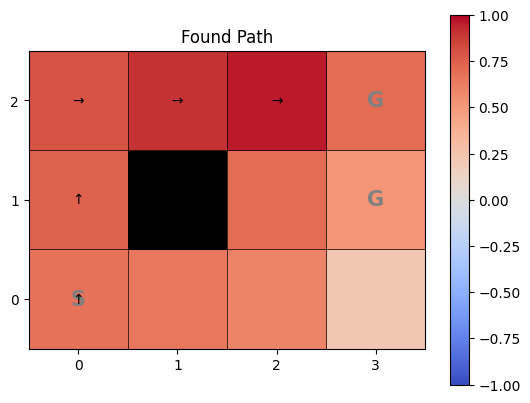

In [23]:
path = sample_episode(env, policy=pol, max_len=100)
env.image(V=np.max(Q, axis = 1), policy=pol, episode=path, title='Found Path', clim=(-1,1))

What is the value of the learned policy?

In [24]:
V_policy = MC_prediction(env, policy=pol, discount=1, n=1000)
V_policy

array([0.75, 0.8 , 0.85, 0.7 , 0.91,  nan, 0.73, 0.96,  nan,  nan,  nan])

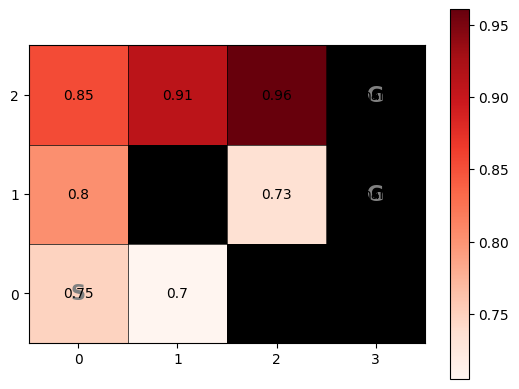

In [25]:
env.image(V=V_policy, labels = True)

So the expected return from the start state is: 

In [26]:
round(V_policy[0], 2)

np.float64(0.75)

### Learning Progress 

To track progress, we save each episode's return.

In [27]:
from tqdm import tqdm

def MC_control_ES_progress(env, discount, n=100, max_episode_len=100, rng=None): 
    rng = np.random.default_rng(rng)
    Returns = defaultdict(list) # a list for each (s,a)
    policy = random_policy(env, rng=rng)
    episode_returns = []
    
    for i in tqdm(range(n)):
        # Sample starting (s,a)
        s = rng.integers(env.observation_space.n)
        a = rng.integers(env.action_space.n)
        
        episode = sample_episode(env, policy, start_state = s, start_action = a, max_len=max_episode_len)
        G = 0
        
        # for first visit check for (s,a)
        visited = [(s,a) for s,a,r,sp in episode]
        
        # process episode in reverse order
        for t in range(len(episode)-1, -1, -1):
            s,a,r,sp = episode[t]
            G = discount * G + r

            # use first visit of (s,a) only
            if not (s,a) in visited[0:t]:
                Returns[(s,a)].append(G)
            
                # update policy
                Q[s,a] = np.mean(Returns[(s,a)])
                policy[s] = random_argmax(Q[s,:], rng)
        
        episode_returns.append(G)
          
    return policy, Q, episode_returns

In [ ]:
# reset environment and algorithm random number generators for the experiment
rng = np.random.default_rng(SEED)
env.reset(seed=SEED)

pol, Q, returns = MC_control_ES_progress(env, discount=1, n=10000, rng=rng)

100%|██████████| 10000/10000 [00:04<00:00, 2165.52it/s]


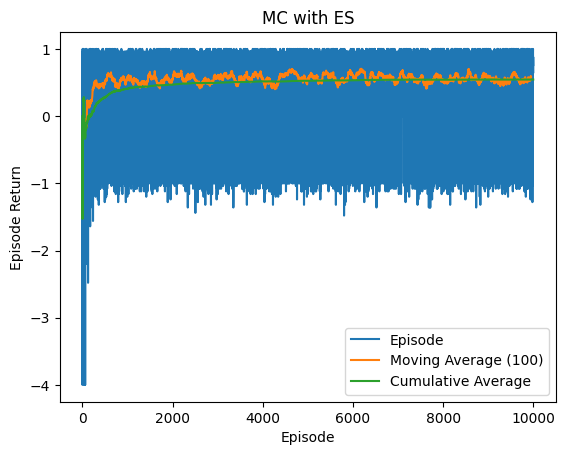

In [39]:
from gym_classics2.performance import plot_returns
plot_returns(returns, title="MC with ES")

Note: Exploring starts is not a real online-RL method because it does not start episodes at the start state. So the rewards we get are for "pieces" of complete episodes; some will be longer and others shorter. Also, if we are unlucky, then the chosen start state/action combination leads us directly into the trap!

### More Algorithms

* On-policy MC control with $\epsilon$-soft policy
* Off-policy MC prediction and control using importance sampling.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)